In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 6 EIA files and combine into one dataframe
import boto3
from io import StringIO

bucket = "gridsense-ai-data-team1"

eia_files = [
    "EIA930_BALANCE_2022_Jan_Jun.csv",
    "EIA930_BALANCE_2022_Jul_Dec.csv",
    "EIA930_BALANCE_2023_Jan_Jun.csv",
    "EIA930_BALANCE_2023_Jul_Dec.csv",
    "EIA930_BALANCE_2024_Jan_Jun.csv",
    "EIA930_BALANCE_2024_Jul_Dec.csv",
]

s3 = boto3.client("s3")
dfs = []

for file in eia_files:
    print(f"Loading {file}...")
    obj = s3.get_object(Bucket=bucket, Key=file)
    df = pd.read_csv(obj["Body"])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {data.shape}")
print(data.head())

Loading EIA930_BALANCE_2022_Jan_Jun.csv...
Loading EIA930_BALANCE_2022_Jul_Dec.csv...
Loading EIA930_BALANCE_2023_Jan_Jun.csv...
Loading EIA930_BALANCE_2023_Jul_Dec.csv...
Loading EIA930_BALANCE_2024_Jan_Jun.csv...
Loading EIA930_BALANCE_2024_Jul_Dec.csv...

Combined shape: (1626431, 74)
  Balancing Authority   Data Date  Hour Number Local Time at End of Hour  \
0                AECI  01/01/2022            1     01/01/2022 1:00:00 AM   
1                AECI  01/01/2022            2     01/01/2022 2:00:00 AM   
2                AECI  01/01/2022            3     01/01/2022 3:00:00 AM   
3                AECI  01/01/2022            4     01/01/2022 4:00:00 AM   
4                AECI  01/01/2022            5     01/01/2022 5:00:00 AM   

  UTC Time at End of Hour  Demand Forecast (MW)  Demand (MW)  \
0   01/01/2022 7:00:00 AM                2235.0       2251.0   
1   01/01/2022 8:00:00 AM                2217.0       2208.0   
2   01/01/2022 9:00:00 AM                2193.0       2204.0  

In [2]:
# Basic data inspection
print("Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)
print("\nMissing Values (count):")
print(data.isnull().sum())
print("\nMissing Values (%):")
print((data.isnull().sum() / len(data) * 100).round(2))

Shape: (1626431, 74)

Data Types:
Balancing Authority                                                          object
Data Date                                                                    object
Hour Number                                                                   int64
Local Time at End of Hour                                                    object
UTC Time at End of Hour                                                      object
                                                                             ...   
Net Generation (MW) from Wind with Integrated Battery Storage (Adjusted)    float64
Net Generation (MW) from Battery Storage (Adjusted)                         float64
Net Generation (MW) from Other Energy Storage (Adjusted)                    float64
Net Generation (MW) from Unknown Energy Storage (Adjusted)                  float64
Net Generation (MW) from Geothermal (Adjusted)                              float64
Length: 74, dtype: object

Missing Values 

In [3]:
# Focus on key columns relevant to grid stress prediction
key_cols = [
    'Balancing Authority',
    'Data Date',
    'Hour Number',
    'Demand Forecast (MW)',
    'Demand (MW)',
    'Net Generation (MW)',
    'Net Generation (MW) from Solar without Integrated Battery Storage',
    'Net Generation (MW) from Wind without Integrated Battery Storage',
    'Net Generation (MW) from Nuclear',
    'Net Generation (MW) from Hydropower Excluding Pumped Storage',
    'Region'
]

df_key = data[key_cols].copy()
print("Shape:", df_key.shape)
print("\nMissing Values (%):")
print((df_key.isnull().sum() / len(df_key) * 100).round(2))

Shape: (1626431, 11)

Missing Values (%):
Balancing Authority                                                   0.00
Data Date                                                             0.00
Hour Number                                                           0.00
Demand Forecast (MW)                                                 14.66
Demand (MW)                                                          14.39
Net Generation (MW)                                                   0.12
Net Generation (MW) from Solar without Integrated Battery Storage    88.34
Net Generation (MW) from Wind without Integrated Battery Storage     91.32
Net Generation (MW) from Nuclear                                     70.96
Net Generation (MW) from Hydropower Excluding Pumped Storage         87.89
Region                                                                0.00
dtype: float64


In [4]:
# Filter to ERCOT region to check null rates for a specific region
ercot = df_key[df_key['Balancing Authority'] == 'ERCO'].copy()
print("ERCOT Shape:", ercot.shape)
print("\nMissing Values (%):")
print((ercot.isnull().sum() / len(ercot) * 100).round(2))
print("\nBalancing Authorities in dataset:")
print(data['Balancing Authority'].value_counts())

ERCOT Shape: (26304, 11)

Missing Values (%):
Balancing Authority                                                   0.00
Data Date                                                             0.00
Hour Number                                                           0.00
Demand Forecast (MW)                                                  0.00
Demand (MW)                                                           0.00
Net Generation (MW)                                                   0.00
Net Generation (MW) from Solar without Integrated Battery Storage    83.21
Net Generation (MW) from Wind without Integrated Battery Storage     83.21
Net Generation (MW) from Nuclear                                      0.00
Net Generation (MW) from Hydropower Excluding Pumped Storage         83.21
Region                                                                0.00
dtype: float64

Balancing Authorities in dataset:
Balancing Authority
AECI    26304
AVA     26304
AVRN    26304
AZPS    26304
BAN

In [5]:
# Convert Data Date to datetime
ercot['Data Date'] = pd.to_datetime(ercot['Data Date'])

# Summary statistics for key numeric columns
print("Summary Statistics - ERCOT:")
print(ercot[['Demand Forecast (MW)', 'Demand (MW)', 'Net Generation (MW)']].describe())

# Check date range
print("\nDate Range:")
print("Start:", ercot['Data Date'].min())
print("End:", ercot['Data Date'].max())

Summary Statistics - ERCOT:
       Demand Forecast (MW)   Demand (MW)  Net Generation (MW)
count          26304.000000  26304.000000         26304.000000
mean           51174.814933  50982.713694         50894.240116
std            11294.620718  11029.138443         10929.164306
min            30412.000000  31949.000000         31806.000000
25%            43176.750000  43003.750000         42988.500000
50%            48172.000000  48021.000000         47941.000000
75%            57061.500000  56973.250000         56851.250000
max            87055.000000  85544.000000         85000.000000

Date Range:
Start: 2022-01-01 00:00:00
End: 2024-12-31 00:00:00


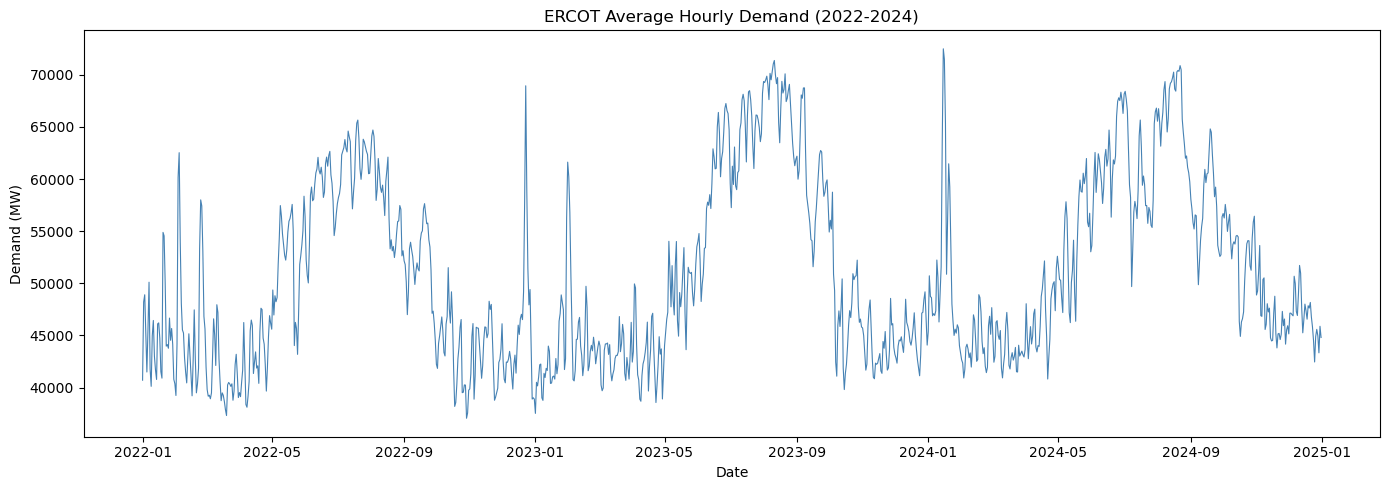

Plot saved.


In [6]:
# Plot daily average demand over time
ercot_daily = ercot.groupby('Data Date')['Demand (MW)'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(ercot_daily['Data Date'], ercot_daily['Demand (MW)'], linewidth=0.8, color='steelblue')
plt.title('ERCOT Average Hourly Demand (2022-2024)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('ercot_demand_over_time.png')
plt.show()
print("Plot saved.")

In [7]:
# Check for duplicates
duplicates = ercot.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check unique balancing authorities and regions
print(f"\nUnique Balancing Authorities: {data['Balancing Authority'].nunique()}")
print(f"Unique Regions: {data['Region'].nunique()}")
print("\nRegions:")
print(data['Region'].value_counts())

Duplicate rows: 0

Unique Balancing Authorities: 63
Unique Regions: 13

Regions:
Region
NW      552384
FLA     236736
SW      226488
CAR     157824
CAL     131520
MIDW     84743
SE       52608
CENT     52608
TEX      26304
NY       26304
NE       26304
MIDA     26304
TEN      26304
Name: count, dtype: int64


## EIA Data Exploration Summary

**Dataset:** EIA930 Balance Files (2022-2024)  
**Shape:** 1,626,431 rows × 74 columns  
**Region Focus:** ERCOT (TEX) — 26,304 hourly records  

### Key Findings
- Data covers January 1, 2022 to December 31, 2024 with no gaps
- No duplicate rows detected
- 63 unique balancing authorities across 13 regions
- ERCOT selected as primary region to align with NREL solar data (Austin, TX)
- Demand and Net Generation columns are 0% null for ERCOT
- Solar, Wind, and Hydro columns are ~83% null for ERCOT due to limited fuel-level reporting in earlier years

### Data Quality Concerns
- Date column loaded as object dtype — converted to datetime
- Many adjusted/imputed columns are near 100% null across all regions and will be dropped in preprocessing
- Solar and wind fuel-level columns have high null rates and may require imputation or alternative sourcing

### Bias Considerations
- **Seasonal bias:** Demand peaks heavily in summer due to Texas climate — model must be trained across all seasons
- **Geographic bias:** ERCOT is focused on Texas only — model predictions may not generalize to other regions
- **Reporting bias:** EIA revises historical data up to 60 days after publication — early records may be less accurate